In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow_datasets as tfds

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## TensorFlow augmentation 7 methods 

In [2]:
# ============================================================
# Part 2: Methods / Models / Training utils
# 第二部分：方法定义 / 模型 / 训练流程（已升级 Level 0/1/2）
# ============================================================

SEED = 42
BATCH_SIZE = 64
EPOCHS = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# EN: A safe "no-op" layer for Method 0 (no augmentation).
# CN: 用于 Method 0 的“空增强层”，避免 Sequential 没有 layer 报错
# -----------------------------
class IdentityLayer(tf.keras.layers.Layer):
    def call(self, x, training=None):
        return x

# -----------------------------
# Level 2 (Learning/Semantic): MixUp helper
# EN: MixUp for batch (x, y). y will be one-hot.
# CN: MixUp 是“学习/语义增强”的代表：按 batch 混合两张图与标签（需要 one-hot 标签）
# -----------------------------
def mixup_batch(x, y_onehot, alpha=0.2):
    """
    EN: Apply MixUp on a batch.
    CN: 对一个 batch 做 MixUp（x与x'线性混合，y也线性混合）
    """
    batch_size = tf.shape(x)[0]
    # EN: Sample lambda from Beta(alpha, alpha).
    # CN: 从 Beta 分布采样混合系数 lambda
    lam = tf.random.gamma(shape=[batch_size], alpha=alpha)
    lam2 = tf.random.gamma(shape=[batch_size], alpha=alpha)
    lam = lam / (lam + lam2 + 1e-8)  # (batch,)

    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])

    # EN: Shuffle within batch.
    # CN: batch 内打乱以配对另一张图
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y_onehot, idx)

    x_mix = x * lam_x + x2 * (1.0 - lam_x)
    y_mix = y_onehot * lam_y + y2 * (1.0 - lam_y)
    return x_mix, y_mix

# -----------------------------
# Level 2 (Learning/Semantic): RandAugment-lite (SAFE)
# EN: Define layers ONCE outside tf.data map to avoid build/tracing errors.
# CN: 关键修复点：不要在 tf.data.map() 里创建 Keras layer，否则会报错/疯狂 retracing
# -----------------------------
RA_ROT = tf.keras.layers.RandomRotation(0.08)  # create once

def randaugment_lite(img, is_rgb: bool, strength=0.2):
    """
    EN: A light RandAugment-style function using safe TF ops.
    CN: 轻量 RandAugment（学习/语义增强方向的一种“更强策略”示例）
        注意：这里只用 TF 原生算子 + 预创建的旋转层，保证 tf.data.map 可运行。
    """
    x = tf.cast(img, tf.float32)

    # EN: Save original size for crop-back.
    # CN: 保存原尺寸，pad 后再随机裁回原尺寸，避免 shape 推断问题
    orig_h = tf.shape(x)[0]
    orig_w = tf.shape(x)[1]
    c = tf.shape(x)[-1]

    # ---- Flip (RGB only) ----
    # EN: Flip is meaningful for many RGB datasets.
    # CN: 翻转对多数 RGB 数据集合理；MNIST/Fashion 一般不建议（数字/衣物方向敏感）
    if is_rgb:
        x = tf.cond(tf.random.uniform([]) < 0.5,
                    lambda: tf.image.flip_left_right(x),
                    lambda: x)

    # ---- Color jitter (RGB only) ----
    # EN: Brightness/contrast jitter for RGB.
    # CN: 亮度/对比度扰动仅对 RGB 有意义，灰度可能破坏结构信息
    if is_rgb:
        def color_jitter():
            y = tf.image.random_brightness(x, max_delta=strength)
            y = tf.image.random_contrast(y, lower=1.0-strength, upper=1.0+strength)
            return y
        x = tf.cond(tf.random.uniform([]) < 0.7, color_jitter, lambda: x)

    # ---- Translation via pad + random crop ----
    # EN: Pad then crop back to original size.
    # CN: 平移用 pad+crop 实现（稳、可控），crop 的 size 必须回到原尺寸
    def translate():
        pad = 4
        y = tf.image.resize_with_crop_or_pad(x, orig_h + pad, orig_w + pad)
        y = tf.image.random_crop(y, size=[orig_h, orig_w, c])
        return y
    x = tf.cond(tf.random.uniform([]) < 0.7, translate, lambda: x)

    # ---- Small rotation (use global layer) ----
    # EN: Use pre-created RandomRotation layer.
    # CN: 使用外部预创建层，避免 tf.data 内创建对象导致报错
    def rotate():
        y = RA_ROT(tf.expand_dims(x, 0), training=True)[0]
        return y
    x = tf.cond(tf.random.uniform([]) < 0.7, rotate, lambda: x)

    return x


# -----------------------------
# EN: Choose TensorFlow augmentation by method_id.
# CN: 按 method_id 选择增强策略（升级版：Level 0/1/2）
#
# Method mapping (建议你在报告里写清楚):
# - Method 0: Level 0  No augmentation
# - Method 1: Level 1  Rotation
# - Method 2: Level 1  Translation
# - Method 3: Level 1  Zoom
# - Method 4: Level 1  Rotation + Translation + Zoom (+ Contrast for RGB)
# - Method 5: Level 2  MixUp (semantic/learning augmentation)
# - Method 6: Level 2  RandAugment-lite (stronger learned-style policy)
# -----------------------------
def get_augmentation(method_id: int, is_rgb: bool) -> tf.keras.Model:
    """
    EN: Return a Keras Sequential augmentation model for Level 0/1.
    CN: Level 0/1 用 Keras layer 实现；Level 2 的 MixUp/RandAugment 在 tf.data.map 中单独处理。
    """
    if method_id == 0:
        return tf.keras.Sequential([IdentityLayer()], name="aug_none")

    layers = []
    if method_id == 1:
        layers.append(tf.keras.layers.RandomRotation(0.08))
    elif method_id == 2:
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
    elif method_id == 3:
        layers.append(tf.keras.layers.RandomZoom(0.10))
    elif method_id == 4:
        layers.append(tf.keras.layers.RandomRotation(0.08))
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
        layers.append(tf.keras.layers.RandomZoom(0.10))
        if is_rgb:
            layers.append(tf.keras.layers.RandomContrast(0.10))
    else:
        # EN: For Level 2 methods, return Identity here (handled in run_one_method).
        # CN: Level 2（MixUp/RandAugment）不在这里做，run_one_method 里处理
        layers.append(IdentityLayer())

    return tf.keras.Sequential(layers, name=f"aug_{method_id}")


# -----------------------------
# EN: Simple CNN baseline (same architecture across methods).
# CN: 统一 CNN 模型结构（保证对比公平）
#     注意：如果你要做“严格的增强效果对比”，模型结构尽量保持一致。
# -----------------------------
def build_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# -----------------------------
# EN: Train one method and return history + final train/val accuracy.
# CN: 训练单个增强方案，返回 history + 最终训练/验证准确率（用于判断过拟合）
#
# IMPORTANT:
# - Level 0/1: standard sparse labels
# - Level 2 MixUp: needs one-hot labels + categorical crossentropy
# -----------------------------
def run_one_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    aug = get_augmentation(method_id, is_rgb)

    # EN: Build base datasets.
    # CN: 构建基础 tf.data
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    # -------------------------
    # EN: For MixUp (Method 5), switch to one-hot labels and different loss.
    # CN: MixUp 需要 one-hot 标签，且用 categorical crossentropy 更合理
    # -------------------------
    use_mixup = (method_id == 5)
    use_randaug = (method_id == 6)

    if use_mixup:
        # EN: rebuild model with categorical crossentropy
        # CN: MixUp 的标签是 soft label（概率分布），所以用 categorical_crossentropy
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=input_shape),

            tf.keras.layers.Conv2D(32, 3, activation="relu"),
            tf.keras.layers.MaxPooling2D(),

            tf.keras.layers.Conv2D(64, 3, activation="relu"),
            tf.keras.layers.MaxPooling2D(),

            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(num_classes, activation="softmax"),
        ])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )

        def train_map(x, y):
            # EN: Apply base augmentation (Level 0/1) first (usually Identity for Method 5).
            # CN: 先做基础增强（对 Method 5 通常是 Identity，但保留接口一致性）
            x = aug(x, training=True)

            # EN: Convert labels to one-hot then MixUp.
            # CN: 转 one-hot + MixUp
            y_oh = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)
            x, y_oh = mixup_batch(x, y_oh, alpha=0.2)
            return x, y_oh

        def val_map(x, y):
            # EN: Validation uses clean data (no augmentation).
            # CN: 验证集不做增强，并把标签也转 one-hot 以匹配 loss
            y_oh = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)
            return x, y_oh

        train_ds2 = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
        val_ds2 = val_ds.map(val_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

        history = model.fit(train_ds2, epochs=EPOCHS, validation_data=val_ds2, verbose=2)

    else:
        # EN: Standard training (sparse labels).
        # CN: 常规训练（sparse labels）
        model = build_cnn(input_shape, num_classes)

        def train_map(x, y):
            # EN: Level 0/1 augmentation by Keras layers.
            # CN: Level 0/1 用 Keras layer 增强
            x = aug(x, training=True)

            # EN: Level 2 RandAugment-lite (Method 6) as extra stronger policy.
            # CN: Level 2：RandAugment-lite（Method 6）在这里额外叠加
            if use_randaug:
                # EN: Apply per-image function safely via map_fn.
                # CN: 对 batch 内每张图做 randaugment_lite（安全版本）
                x = tf.map_fn(
                    lambda img: randaugment_lite(img, is_rgb=is_rgb, strength=0.2),
                    x,
                    fn_output_signature=tf.float32
                )
            return x, y

        train_ds2 = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
        val_ds2 = val_ds.prefetch(tf.data.AUTOTUNE)

        history = model.fit(train_ds2, epochs=EPOCHS, validation_data=val_ds2, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc


# -----------------------------
# EN: Plot accuracy + loss curves.
# CN: 画训练/验证 accuracy 和 loss 曲线（每个 method 一张）
# -----------------------------
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_final_summary(results_dict, title="Final Train / Val Accuracy by Method"):
    """
    EN: Plot final train/val accuracy across methods as line plots.
    CN: 使用折线图展示不同方法的最终训练/验证准确率
    """
    methods = sorted(results_dict.keys())
    train_acc = [results_dict[m][0] for m in methods]
    val_acc   = [results_dict[m][1] for m in methods]

    plt.figure(figsize=(8, 5))
    plt.plot(methods, train_acc, marker="o", label="Train Accuracy")
    plt.plot(methods, val_acc, marker="s", label="Validation Accuracy")

    plt.xticks(methods)
    plt.xlabel("Method ID")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

##  SVHN


SVHN - Method 0



Epoch 1/10
1242/1242 - 8s - 7ms/step - accuracy: 0.7399 - loss: 0.8546 - val_accuracy: 0.8387 - val_loss: 0.5663
Epoch 2/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8658 - loss: 0.4827 - val_accuracy: 0.8762 - val_loss: 0.4333
Epoch 3/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8859 - loss: 0.3960 - val_accuracy: 0.8870 - val_loss: 0.3893
Epoch 4/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9005 - loss: 0.3448 - val_accuracy: 0.8915 - val_loss: 0.3725
Epoch 5/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9097 - loss: 0.3070 - val_accuracy: 0.8967 - val_loss: 0.3568
Epoch 6/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9187 - loss: 0.2763 - val_accuracy: 0.9012 - val_loss: 0.3525
Epoch 7/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9266 - loss: 0.2502 - val_accuracy: 0.8999 - val_loss: 0.3500
Epoch 8/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9338 - loss: 0.2279 - val_accuracy: 0.8995 - val_loss: 0.3566
Epoch 9/10
1242/1242 - 8s - 6ms/step - accuracy: 0.9394 - loss: 0.2068 - val_accuracy: 0.9051 - 

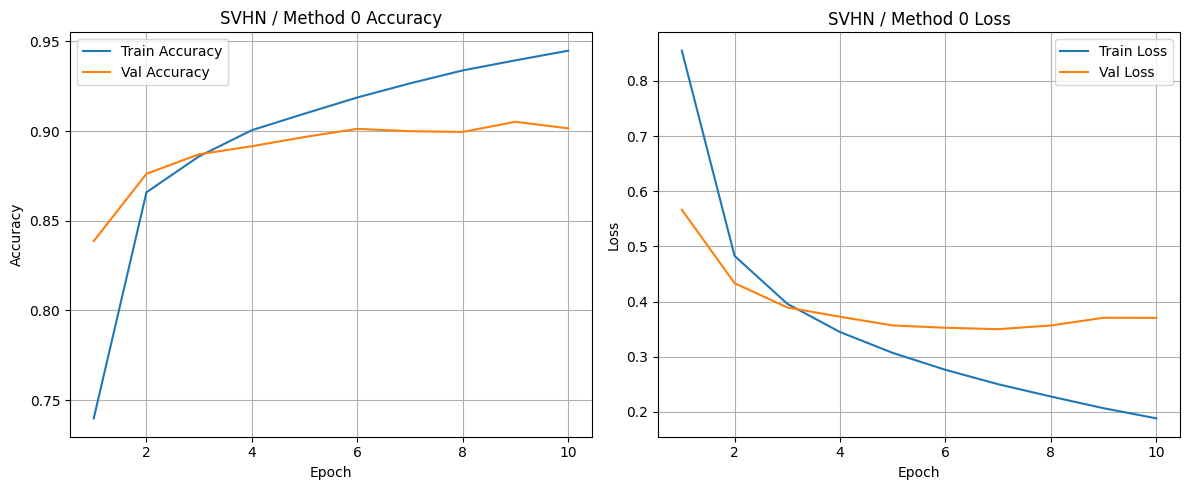


SVHN - Method 1
Epoch 1/10
1242/1242 - 9s - 7ms/step - accuracy: 0.6385 - loss: 1.1362 - val_accuracy: 0.8133 - val_loss: 0.6568
Epoch 2/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8022 - loss: 0.6774 - val_accuracy: 0.8433 - val_loss: 0.5491
Epoch 3/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8312 - loss: 0.5719 - val_accuracy: 0.8584 - val_loss: 0.4881
Epoch 4/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8460 - loss: 0.5185 - val_accuracy: 0.8554 - val_loss: 0.4815
Epoch 5/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8584 - loss: 0.4747 - val_accuracy: 0.8682 - val_loss: 0.4533
Epoch 6/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8686 - loss: 0.4423 - val_accuracy: 0.8804 - val_loss: 0.4104
Epoch 7/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8743 - loss: 0.4203 - val_accuracy: 0.8824 - val_loss: 0.4046
Epoch 8/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8808 - loss: 0.4019 - val_accuracy: 0.8863 - val_loss: 0.3932
Epoch 9/10
1242/1242 - 8s - 7ms/step - accuracy: 0.8853 - loss: 0.3866 - val_ac

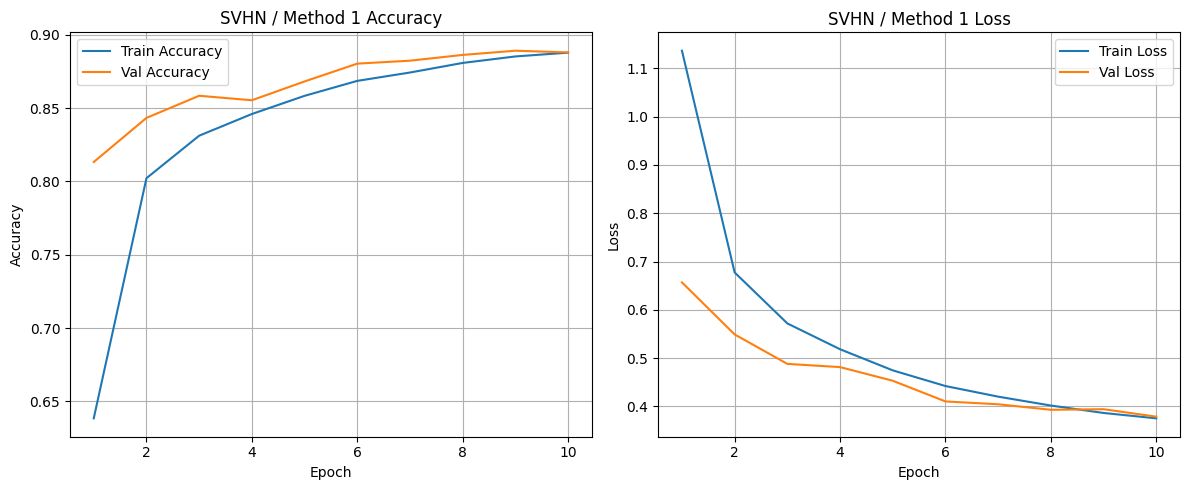


SVHN - Method 2
Epoch 1/10
1242/1242 - 9s - 7ms/step - accuracy: 0.6426 - loss: 1.1282 - val_accuracy: 0.8304 - val_loss: 0.6007
Epoch 2/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8105 - loss: 0.6549 - val_accuracy: 0.8723 - val_loss: 0.4617
Epoch 3/10
1242/1242 - 8s - 7ms/step - accuracy: 0.8406 - loss: 0.5470 - val_accuracy: 0.8854 - val_loss: 0.4116
Epoch 4/10
1242/1242 - 8s - 7ms/step - accuracy: 0.8560 - loss: 0.4843 - val_accuracy: 0.8926 - val_loss: 0.3747
Epoch 5/10
1242/1242 - 9s - 7ms/step - accuracy: 0.8668 - loss: 0.4514 - val_accuracy: 0.8943 - val_loss: 0.3630
Epoch 6/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8765 - loss: 0.4170 - val_accuracy: 0.9015 - val_loss: 0.3431
Epoch 7/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8839 - loss: 0.3965 - val_accuracy: 0.9062 - val_loss: 0.3270
Epoch 8/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8883 - loss: 0.3802 - val_accuracy: 0.9084 - val_loss: 0.3218
Epoch 9/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8931 - loss: 0.3602 - val_ac

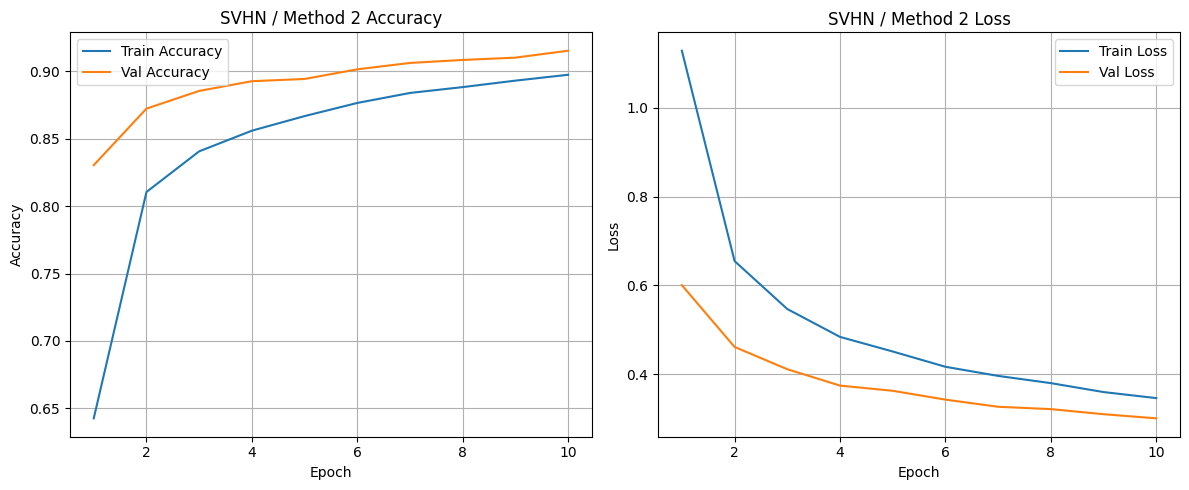


SVHN - Method 3
Epoch 1/10
1242/1242 - 9s - 7ms/step - accuracy: 0.7068 - loss: 0.9446 - val_accuracy: 0.8258 - val_loss: 0.6089
Epoch 2/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8581 - loss: 0.5126 - val_accuracy: 0.8716 - val_loss: 0.4588
Epoch 3/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8776 - loss: 0.4300 - val_accuracy: 0.8832 - val_loss: 0.4095
Epoch 4/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8910 - loss: 0.3792 - val_accuracy: 0.8876 - val_loss: 0.3827
Epoch 5/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8999 - loss: 0.3447 - val_accuracy: 0.8894 - val_loss: 0.3757
Epoch 6/10
1242/1242 - 8s - 6ms/step - accuracy: 0.9072 - loss: 0.3156 - val_accuracy: 0.8959 - val_loss: 0.3627
Epoch 7/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9138 - loss: 0.2951 - val_accuracy: 0.9017 - val_loss: 0.3399
Epoch 8/10
1242/1242 - 8s - 6ms/step - accuracy: 0.9190 - loss: 0.2755 - val_accuracy: 0.9015 - val_loss: 0.3417
Epoch 9/10
1242/1242 - 8s - 6ms/step - accuracy: 0.9238 - loss: 0.2607 - val_ac

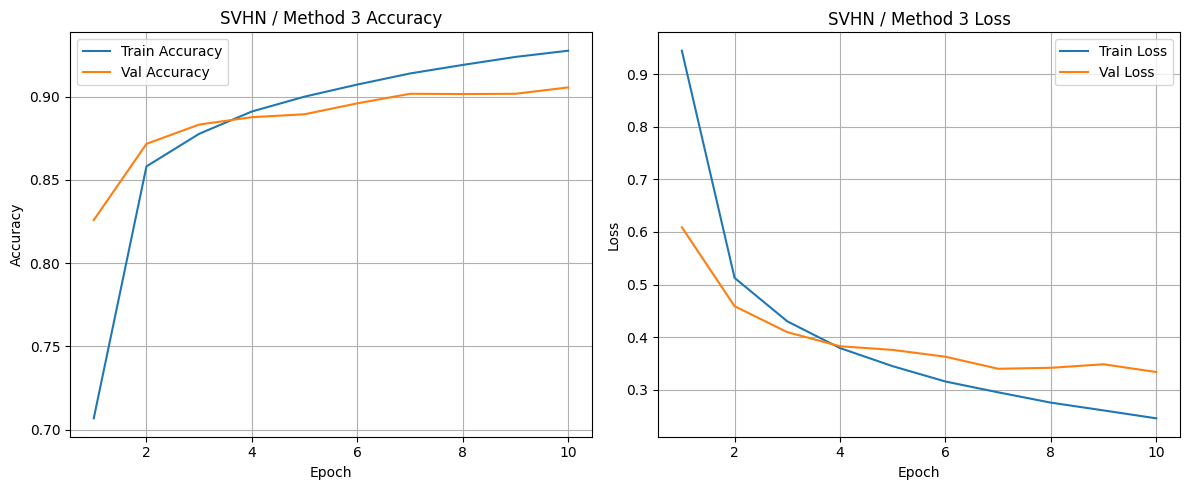


SVHN - Method 4
Epoch 1/10
1242/1242 - 9s - 8ms/step - accuracy: 0.5405 - loss: 1.4001 - val_accuracy: 0.8081 - val_loss: 0.6770
Epoch 2/10
1242/1242 - 8s - 7ms/step - accuracy: 0.7372 - loss: 0.8685 - val_accuracy: 0.8413 - val_loss: 0.5417
Epoch 3/10
1242/1242 - 8s - 6ms/step - accuracy: 0.7744 - loss: 0.7399 - val_accuracy: 0.8567 - val_loss: 0.4806
Epoch 4/10
1242/1242 - 8s - 6ms/step - accuracy: 0.7972 - loss: 0.6645 - val_accuracy: 0.8692 - val_loss: 0.4522
Epoch 5/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8125 - loss: 0.6130 - val_accuracy: 0.8661 - val_loss: 0.4471
Epoch 6/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8243 - loss: 0.5797 - val_accuracy: 0.8749 - val_loss: 0.4258
Epoch 7/10
1242/1242 - 8s - 7ms/step - accuracy: 0.8330 - loss: 0.5476 - val_accuracy: 0.8859 - val_loss: 0.3955
Epoch 8/10
1242/1242 - 8s - 7ms/step - accuracy: 0.8389 - loss: 0.5284 - val_accuracy: 0.8877 - val_loss: 0.3822
Epoch 9/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8459 - loss: 0.5103 - val_ac

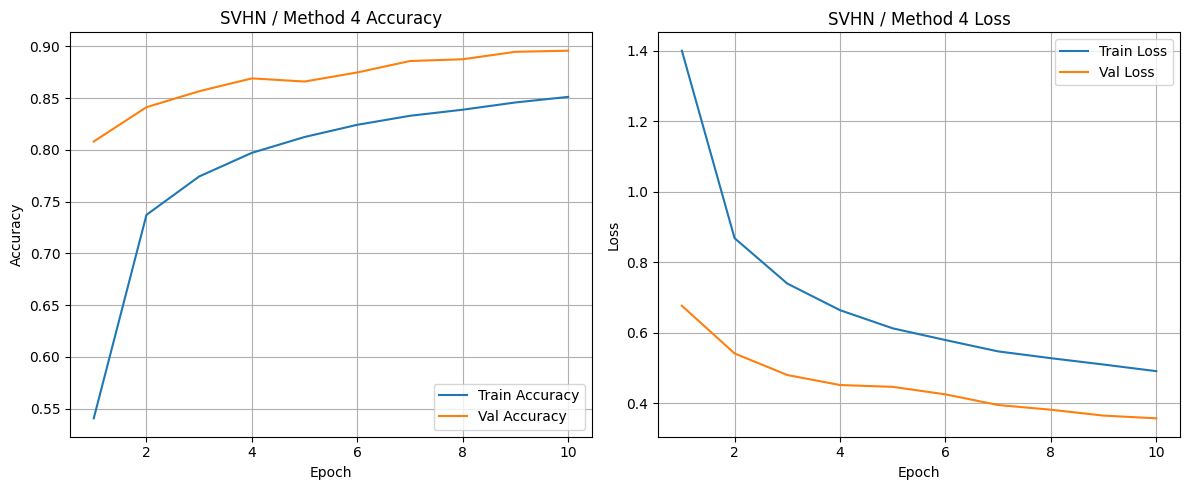


SVHN - Method 5
Epoch 1/10
1242/1242 - 8s - 7ms/step - accuracy: 0.6224 - loss: 1.3457 - val_accuracy: 0.8278 - val_loss: 0.6646
Epoch 2/10
1242/1242 - 7s - 6ms/step - accuracy: 0.7977 - loss: 0.9331 - val_accuracy: 0.8547 - val_loss: 0.5419
Epoch 3/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8181 - loss: 0.8593 - val_accuracy: 0.8674 - val_loss: 0.5059
Epoch 4/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8300 - loss: 0.8220 - val_accuracy: 0.8788 - val_loss: 0.4618
Epoch 5/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8394 - loss: 0.7954 - val_accuracy: 0.8813 - val_loss: 0.4623
Epoch 6/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8466 - loss: 0.7741 - val_accuracy: 0.8854 - val_loss: 0.4241
Epoch 7/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8508 - loss: 0.7625 - val_accuracy: 0.8858 - val_loss: 0.4411
Epoch 8/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8561 - loss: 0.7449 - val_accuracy: 0.8973 - val_loss: 0.3874
Epoch 9/10
1242/1242 - 8s - 7ms/step - accuracy: 0.8615 - loss: 0.7306 - val_ac

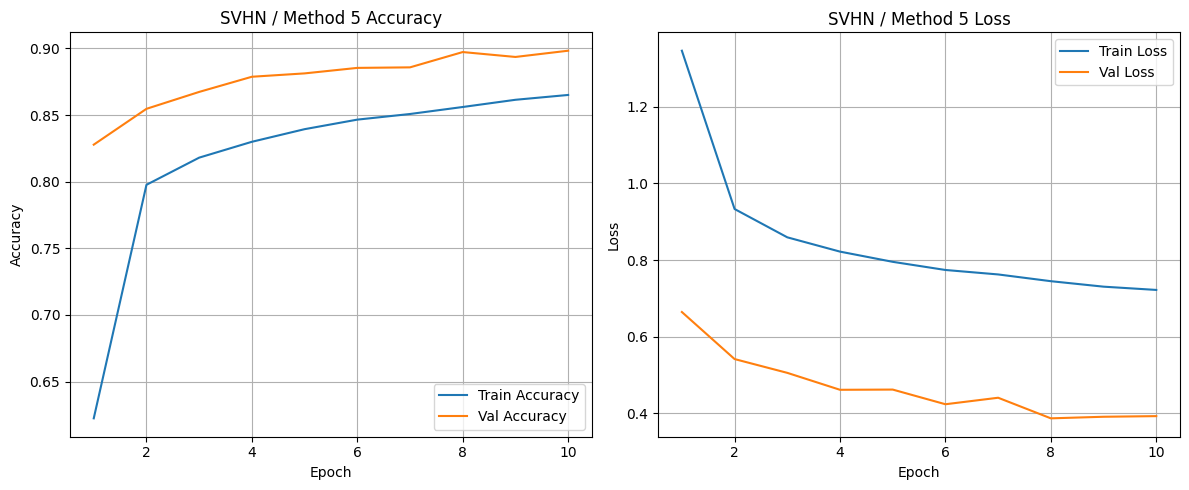


SVHN - Method 6
Epoch 1/10
1242/1242 - 15s - 12ms/step - accuracy: 0.5043 - loss: 1.4755 - val_accuracy: 0.7263 - val_loss: 0.8720
Epoch 2/10
1242/1242 - 13s - 10ms/step - accuracy: 0.6827 - loss: 0.9979 - val_accuracy: 0.7791 - val_loss: 0.7155
Epoch 3/10
1242/1242 - 13s - 10ms/step - accuracy: 0.7265 - loss: 0.8625 - val_accuracy: 0.8177 - val_loss: 0.5985
Epoch 4/10
1242/1242 - 13s - 11ms/step - accuracy: 0.7581 - loss: 0.7670 - val_accuracy: 0.8260 - val_loss: 0.5667
Epoch 5/10
1242/1242 - 13s - 10ms/step - accuracy: 0.7778 - loss: 0.7066 - val_accuracy: 0.8389 - val_loss: 0.5166
Epoch 6/10
1242/1242 - 13s - 10ms/step - accuracy: 0.7910 - loss: 0.6652 - val_accuracy: 0.8500 - val_loss: 0.4863
Epoch 7/10
1242/1242 - 13s - 10ms/step - accuracy: 0.8001 - loss: 0.6360 - val_accuracy: 0.8536 - val_loss: 0.4705
Epoch 8/10
1242/1242 - 13s - 11ms/step - accuracy: 0.8088 - loss: 0.6101 - val_accuracy: 0.8619 - val_loss: 0.4466
Epoch 9/10
1242/1242 - 13s - 10ms/step - accuracy: 0.8151 - los

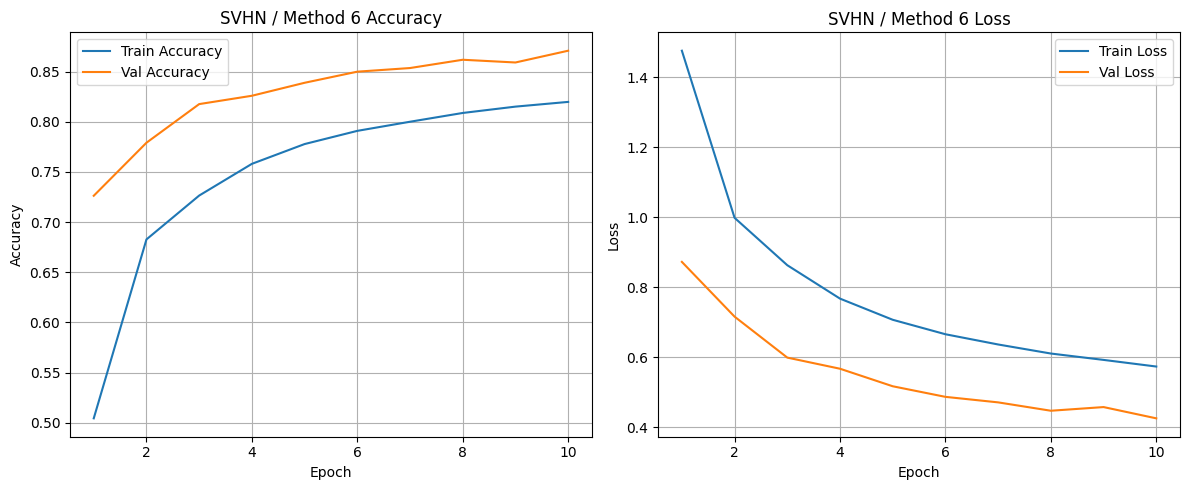


SVHN - Method 7
Epoch 1/10
1242/1242 - 8s - 7ms/step - accuracy: 0.7274 - loss: 0.8939 - val_accuracy: 0.8421 - val_loss: 0.5693
Epoch 2/10
1242/1242 - 7s - 6ms/step - accuracy: 0.8642 - loss: 0.4934 - val_accuracy: 0.8737 - val_loss: 0.4451
Epoch 3/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8831 - loss: 0.4114 - val_accuracy: 0.8836 - val_loss: 0.4117
Epoch 4/10
1242/1242 - 8s - 6ms/step - accuracy: 0.8961 - loss: 0.3599 - val_accuracy: 0.8896 - val_loss: 0.3828
Epoch 5/10
1242/1242 - 8s - 6ms/step - accuracy: 0.9065 - loss: 0.3240 - val_accuracy: 0.8892 - val_loss: 0.3818
Epoch 6/10
1242/1242 - 8s - 6ms/step - accuracy: 0.9151 - loss: 0.2934 - val_accuracy: 0.8998 - val_loss: 0.3754
Epoch 7/10
1242/1242 - 8s - 6ms/step - accuracy: 0.9220 - loss: 0.2672 - val_accuracy: 0.9010 - val_loss: 0.3495
Epoch 8/10
1242/1242 - 7s - 6ms/step - accuracy: 0.9284 - loss: 0.2452 - val_accuracy: 0.9000 - val_loss: 0.3581
Epoch 9/10
1242/1242 - 8s - 6ms/step - accuracy: 0.9342 - loss: 0.2234 - val_ac

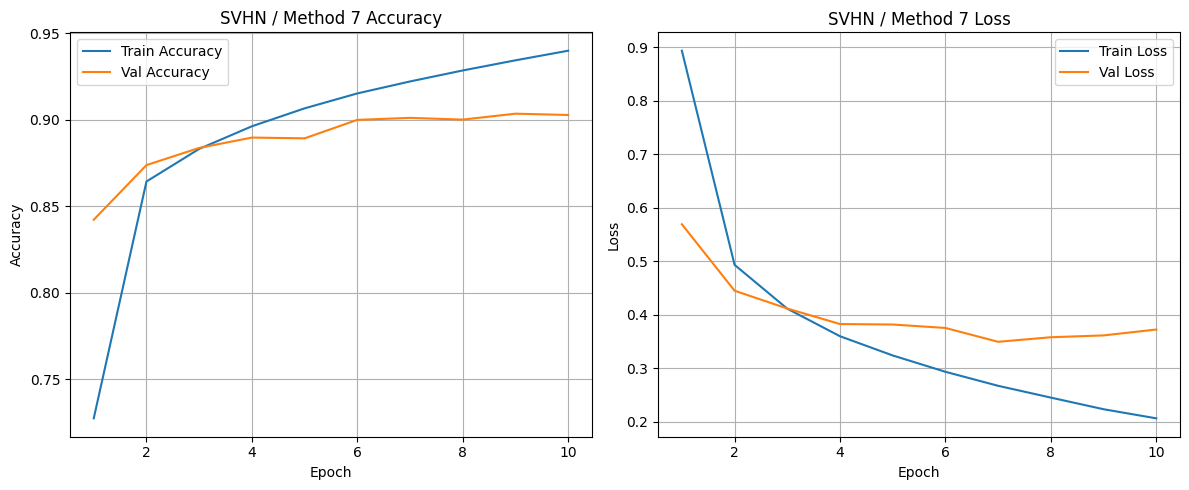


Final accuracy summary (SVHN):
Method 0: train_acc=0.9447, val_acc=0.9015
Method 1: train_acc=0.8878, val_acc=0.8880
Method 2: train_acc=0.8974, val_acc=0.9152
Method 3: train_acc=0.9275, val_acc=0.9055
Method 4: train_acc=0.8513, val_acc=0.8959
Method 5: train_acc=0.8651, val_acc=0.8983
Method 6: train_acc=0.8198, val_acc=0.8709
Method 7: train_acc=0.9398, val_acc=0.9027


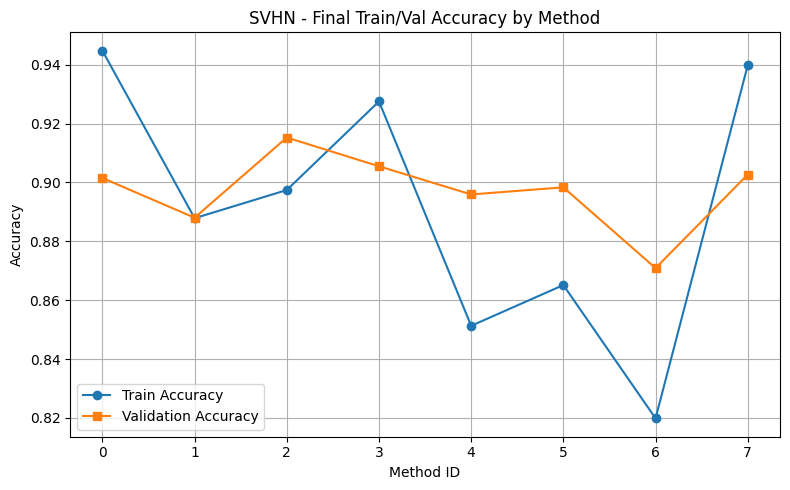

In [3]:
# =========================
# SVHN (TFDS)
# =========================
ds = tfds.load("svhn_cropped", split="train+test", as_supervised=True)

images = []
labels = []
for img, lab in tfds.as_numpy(ds):
    images.append(img)
    labels.append(lab)

X = np.stack(images).astype("float32") / 255.0
y = np.array(labels).astype("int64")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (32, 32, 3)
num_classes = 10
is_rgb = True

results = {}

for method_id in range(8):
    print("\n==============================")
    print(f"SVHN - Method {method_id}")
    print("==============================")

    history, train_acc, val_acc = run_one_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape, num_classes=num_classes,
        method_id=method_id, is_rgb=is_rgb
    )
    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"SVHN / Method {method_id}")

print("\nFinal accuracy summary (SVHN):")
for k, (ta, va) in results.items():
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")

plot_final_summary(results, title="SVHN - Final Train/Val Accuracy by Method")